<a href="https://colab.research.google.com/github/meghana2343/datascience/blob/main/gaussian_processes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
PART 1 OF THE. GAUSSIAN PROCESS

In [3]:
#Import packages
import torch
from torch import nn
import math
import matplotlib.pyplot as plt
# Setting a seed for reproducibility.
torch.manual_seed(42)

generating  some intial  code

In [8]:
train_data_length = 1024
train_data = torch.zeros((train_data_length, 2))
train_data[:, 0] = 2.0 * math.pi * torch.rand(train_data_length)
train_data[:, 1] = torch.sin(train_data[:, 0])
train_labels = torch.zeros(train_data_length)
train_set = [(train_data[i], train_labels[i]) for i in
range(train_data_length)]


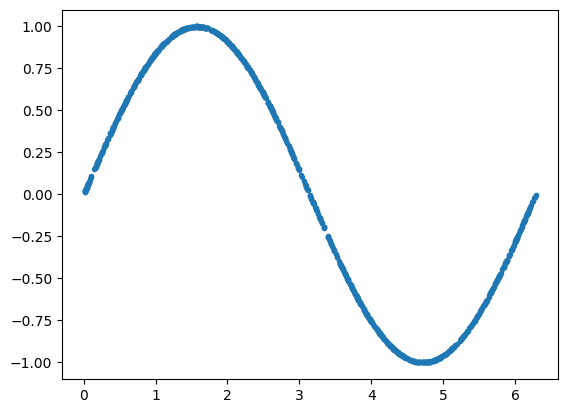

In [17]:
plt.plot(train_data[:, 0], train_data[:, 1], ".")
plt.show()

In [44]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)

In [45]:
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
    nn.Linear(2, 256),
    nn.ReLU(), # activation function
    nn.Dropout(0.3), # dropout to prevent overfitting
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 1),
    nn.Sigmoid(), # sigmoid activation to produce a probability
    )

  # Describe how the forward pass is calculated.
  def forward(self, x):
    output = self.model(x)
    return output
# After declaring the discriminator class, we instantiate a discriminator object.
discriminator = Discriminator()

In [43]:
class Generator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(2, 64),
        nn.ReLU(),
        nn.Linear(64, 128),
        nn.ReLU(),
        nn.Linear(128, 256),
        nn.ReLU(),
        nn.Linear(256, 2),
    )

  def forward(self, x):
    output = self.model(x)
    return output

generator = Generator()

# Re-instantiate discriminator to ensure it uses the latest class definition
discriminator = Discriminator()

# Define loss function and optimizers (these were also undefined in the traceback)
loss_function = nn.BCEWithLogitsLoss()
optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=0.0001)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=0.0001)

num_epochs = 2000 # Define the number of epochs
for epoch in range(num_epochs):
  for n, (real_samples, _) in enumerate(train_loader):
# Data for training the discriminator.
    real_samples_labels = torch.ones((batch_size, 1))
    latent_space_samples = torch.randn((batch_size, 2))
    generated_samples = generator(latent_space_samples)
    generated_samples_labels = torch.zeros((batch_size, 1))
    all_samples = torch.cat((real_samples, generated_samples))
    all_samples_labels = torch.cat((real_samples_labels,
    generated_samples_labels))
    # Training the discriminator.
    discriminator.zero_grad()
    output_discriminator = discriminator(all_samples)
    loss_discriminator = loss_function(output_discriminator,
      all_samples_labels)
    loss_discriminator.backward()
    optimizer_discriminator.step()
    # Data for training the generator.
    latent_space_samples = torch.randn((batch_size, 2))
    # Training the generator.
    generator.zero_grad()
    generated_samples = generator(latent_space_samples)
    output_discriminator_generated = discriminator(generated_samples)
    loss_generator = loss_function(output_discriminator_generated, real_samples_labels)
    loss_generator.backward()
    optimizer_generator.step()
    # Print loss at various training stages.
    print_epoch_num = (100 )# Change this depending on often the loss should be printed.

    if epoch % print_epoch_num == 0 and n == batch_size - 1:
        print(f"Epoch: {epoch} Loss D.: {loss_discriminator}")
        print(f"Epoch: {epoch} Loss G.: {loss_generator}")

Epoch: 0 Loss D.: 0.6997158527374268
Epoch: 0 Loss G.: 0.47613582015037537
Epoch: 100 Loss D.: 0.6931531429290771
Epoch: 100 Loss G.: 0.6931335926055908
Epoch: 200 Loss D.: 0.6931506395339966
Epoch: 200 Loss G.: 0.6931453347206116
Epoch: 300 Loss D.: 0.6931473612785339
Epoch: 300 Loss G.: 0.6931469440460205
Epoch: 400 Loss D.: 0.6931471824645996
Epoch: 400 Loss G.: 0.6931471228599548
Epoch: 500 Loss D.: 0.6931471824645996
Epoch: 500 Loss G.: 0.6931471824645996
Epoch: 600 Loss D.: 0.6931471824645996
Epoch: 600 Loss G.: 0.6931471824645996
Epoch: 700 Loss D.: 0.6931471824645996
Epoch: 700 Loss G.: 0.6931471824645996
Epoch: 800 Loss D.: 0.6931471824645996
Epoch: 800 Loss G.: 0.6931471824645996
Epoch: 900 Loss D.: 0.6931471824645996
Epoch: 900 Loss G.: 0.6931471824645996
Epoch: 1000 Loss D.: 0.6931471824645996
Epoch: 1000 Loss G.: 0.6931471824645996
Epoch: 1100 Loss D.: 0.6931471824645996
Epoch: 1100 Loss G.: 0.6931471824645996
Epoch: 1200 Loss D.: 0.6931471824645996
Epoch: 1200 Loss G.: 0.

In [46]:
 #Generate 1000 random 2D points and feed them to the generator.
latent_space_samples = torch.randn(1000, 2)
generated_samples = generator(latent_space_samples)
# Turn the PyTorch tensor into a NumPy array.
generated_samples_numpy = generated_samples.detach().numpy()

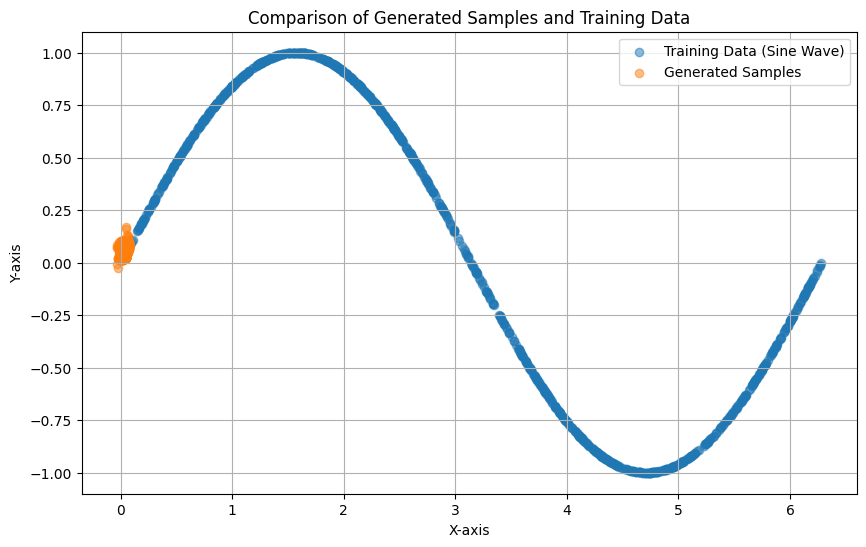

In [47]:
plt.figure(figsize=(10, 6))
plt.scatter(train_data[:, 0], train_data[:, 1], label='Training Data (Sine Wave)', alpha=0.5)
plt.scatter(generated_samples_numpy[:, 0], generated_samples_numpy[:, 1], label='Generated Samples', alpha=0.5)
plt.title('Comparison of Generated Samples and Training Data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True)
plt.show()